<h1 style="text-align: center;"> Striver Binary Search - Binary Search on Answers </h1>

# 1. Find Square Root of a Number in log N :

## Problem Statement :

Given a positive integer n. Find and return its square root. If n is not a perfect square, then return the floor value of sqrt(n).


### Examples :

**Example 1:**
```
Input: n = 36
Output: 6

Explanation: 6 is the square root of 36.
```

**Example 2:**
```
Input: n = 28
Output: 5

Explanation: The square root of 28 is approximately 5.292. So, the floor value will be 5.
```

```
Constraints:
0 <= n <= 2^31 - 1
```

# Linear Search

### Intuition

The idea here is to search for the floor of the square root of the given number linearly. For each number from 1 to the given number, find its square and check if it is smaller than the given number. If it is, store the current integer as potential root, else break out of the loop as the further calculations will only provide larger square roots.

### Approach

* Start with ans initialized to 0, which will eventually hold the floor of the square root of n.
* Iterate using a for loop, ranging from 1 to n. For each integer compute 'val' as the square of the current integer.
* Check if 'val' is less than or equal to n. If true update 'ans' to the current value of the integer, because the current integer is a candidate for the square root.
* If val exceeds n, break out of the loop since further values of the next integer will only yield larger squares.
* Once the loop completes, ans contains the largest integer such that ans * ans is less than or equal to n, providing the floor of the square root of n. Finally return ans.

## Linear Search Python Solution

In [16]:
class Solution:
    """ Function to compute the floor of square root
       of a given integer """
    def floorSqrt(self, n: int) -> int:
        ans = 0
        
        # Linear search in the answer space
        for i in range(1, n + 1):
            val = i * i
            # Check if val is less than or equal to n
            if val <= n:
                ans = i  # Update ans to current value of i
            else:
                break  # Exit loop if val exceeds n
        
        # Return the computed floor of square root
        return ans

In [17]:
def main():
    n = 28
    
    # Create an object of the Solution class
    sol = Solution()
    
    ans = sol.floorSqrt(n)
    
    # Print the result
    print(f"The floor of square root of {n} is: {ans}")


if __name__ == "__main__":
    main()

The floor of square root of 28 is: 5


## Complexity Analysis

**Time Complexity:**

The Time Complexity will be  O($N^1/2$), where N is the given number. This is the case because we are using Linear Search, and the loop iterates up to sqrt(N) before breaking out.

**Space Complexity:**

The Space Complexity will be O(1) as no additional space is used.

# Binary Search

### Intuition

Binary Search algorithm can be used to optimize the Brute Force solution of Linear Search. While applying the Binary Search algorithm, compare the square of mid with the given number, if the square is less than or equal to the given number, store the mid as it can be a potential root and eliminate the left half of the search space, and eliminate the right half otherwise.

### Approach

* Start with initializing low to 1 and high initialized to n, where n is the given number, defining the search range for ans. Also, initialize ans to 0 to store the answer.
* Use a while loop, where it continues to search until low exceeds high. Calculate 'mid' as the midpoint between low and high. Compute val as mid * mid, the square of the midpoint.
* Check if 'val' is less than or equal to n. if true, it means mid could be a potential candidate for the square root. Store the mid in 'ans' and move the search to the right part by updating low to mid + 1. If false, move the search to the left part by updating high to mid - 1 because mid is too high and mid * mid exceeds n
* Once the while loop exits, 'ans' holds the largest integer ans such that ans * ans does not exceed n.

## Dry Run

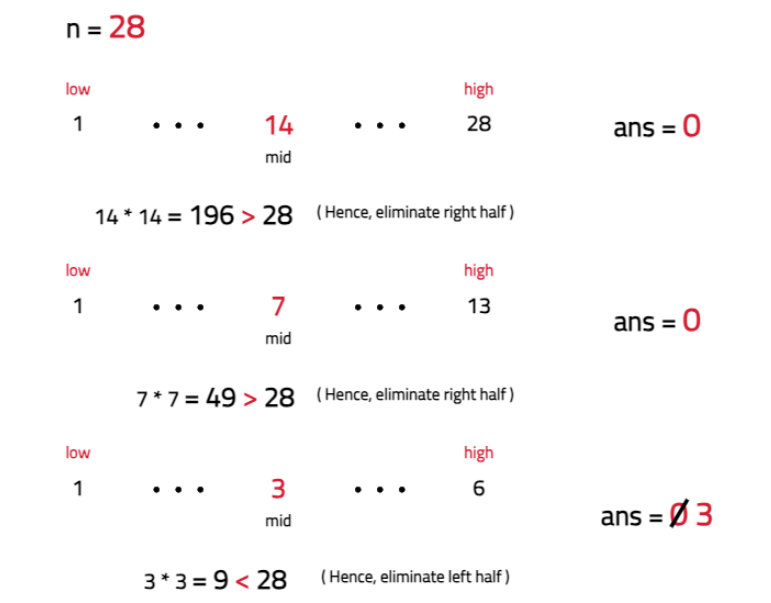
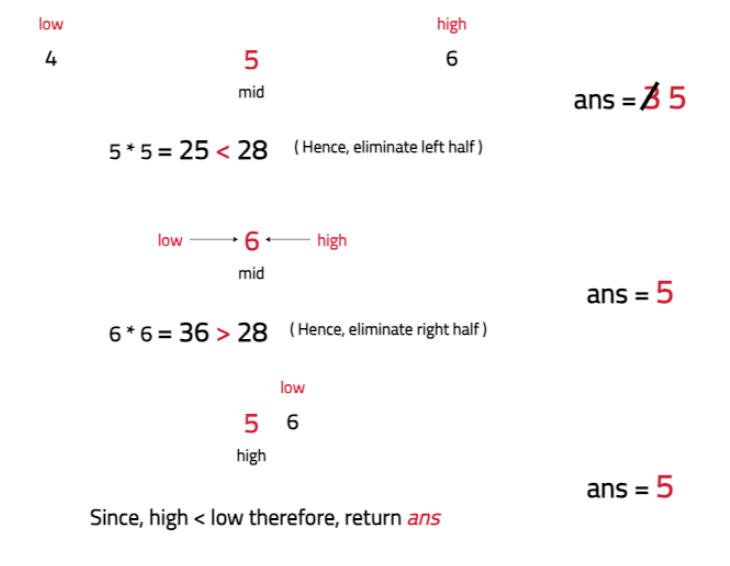

## Binary Search Python Solution

In [18]:
class Solution:
    """ Function to compute the floor of
       square root of a given integer """
    def floorSqrt(self, n: int) -> int:
        low, high = 1, n
        
        # Binary search on the answer space
        while low <= high:
            mid = low + (high - low) // 2
            val = mid * mid  # Python ints are unbounded
            
            # Check if val is less than or equal to n
            if val <= n:
                # Move to the right part
                low = mid + 1
            else:
                # Move to the left part
                high = mid - 1
        
        # Return the floor of square root
        return high

In [19]:
def main():
    n = 28
    
    # Create an object of the Solution class
    sol = Solution()
    
    ans = sol.floorSqrt(n)
    
    # Print the result
    print(f"The floor of square root of {n} is: {ans}")


if __name__ == "__main__":
    main()

The floor of square root of 28 is: 5


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(logN), where N is the given number. We are basically using the Binary Search algorithm.
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no additional space is used in this case.
```

## FAQs & Interview Follow-ups :

**How do we avoid integer overflow when computing mid^2?**
```
Instead of directly calculating mid^2, compare mid with n/mid. If mid > n / mid, mid^2 exceeds n, and you should move left. This ensures safe arithmetic even for large n.
```

**What happens if n is a perfect square?**
```
The binary search naturally finds the exact square root when mid^2 == n. The result is returned directly without additional steps.
```

**What if the function needs to work in real-time systems?**
```
Use approximation techniques like Newton’s method, which converges quickly and is well-suited for systems requiring rapid results.
```

**How would you compute the square root for floating-point numbers?**
```
For floating-point numbers, extend the Binary Search to calculate the square root up to a desired precision (ϵ): Continue the search until ∣mid^2−n∣<ϵ. Update low and high with smaller increments as the range narrows.
```

# 2. Find the Nth Root of a Number using Binary Search :

## Problem Statement :

Given two numbers N and M, find the Nth root of M. The Nth root of a number M is defined as a number X such that when X is raised to the power of N, it equals M. If the Nth root is not an integer, return -1.


### Examples :

**Example 1:**
```
Input: N = 3, M = 27
Output: 3

Explanation: The cube root of 27 is equal to 3.
```

**Example 2:**
```
Input: N = 4, M = 69
Output:-1

Explanation: The 4th root of 69 does not exist. So, the answer is -1.
```

```
Constraints:
1 <= N <= 30
1 <= M <= 10^9
```

# Linear Search

### Intuition

Perform a simple Linear Search in range [1,M]. Calculate the value of x raised to the power N for every number x in this range. If it is equal to the given number then, x is the Nth root of the number. If no such number (x) exists, return -1 as an answer.

### Approach and the Working of nthRoot(N, M):

* Iterate from 1 to M(given number) using a for loop. Calculate the value of x raised to the power n as follows:

```
Start with the result as 1 and keep track of the base value.
If the exponent is odd, multiply the result by the base and reduce the exponent by one.
If the exponent is even, square the base and half the exponent.
Continue the process until the exponent becomes zero, and the final result is returned.
```

* If the result is equal to M, this means x is the Nth root of M. So, return x from this step.
* If the calculated value is smaller than M, then continue to next iteration.
* If the calculated value is greater than M, this means we have got a bigger number than our answer and until now we have not found any number that can be our answer. In this case, our answer does not exist and break out from this step and return -1.

## Linear Search Python Solution

In [20]:
class Solution:
    """ Function to calculate power using
    exponentiation by squaring method"""
    def Pow(self, b, exp):
        ans = 1
        base = b
        
        # Exponentiation by squaring method
        while exp > 0:
            if exp % 2 == 1:
                exp -= 1
                ans *= base
            else:
                exp //= 2
                base *= base
        return ans

    """ Function to find the nth root
        of m using linear search"""
    def NthRoot(self, N: int, M: int) -> int:
        # Linear search on the answer space
        for i in range(1, M + 1):
            val = self.Pow(i, N)

            """ Check if the computed
            value is equal to M"""
            if val == M:
                # Return the root value
                return i
            elif val > M:
                break
        # Return -1 if no root found
        return -1

In [21]:
# Driver code
if __name__ == "__main__":
    n, m = 3, 27
    
    # Create an object of the Solution class
    sol = Solution()
    
    ans = sol.NthRoot(n, m)
    
    # Print the result
    print(f"The answer is: {ans}")

The answer is: 3


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N*logN). This is because the for loop runs takes O(M) time and calculating Pow(x, N) takes O(logN) time. However, since the for loop breaks as soon as the result of Pow(x, N) becomes greater than M, thus, the for loops actually runs only for N iterations making overall complexity as O(N*logN).
```

**Space Complexity:**
```
The Space Complexity will be O(1), as there are only a couple of variables used.
```

# Binary Search

### Intuition

The idea here is to use Binary Search to optimize the solution. Although the traditional application of Binary Search involves a sorted array, upon closer observation, one can notice that the search space for the answer here ranges from 1 to M, which inherently forms a sorted sequence. So, binary search can be applied.

## Approach

<b>Need of a helper function to find the exponent of the number:</b> If the given numbers M and N are big enough, the value of mid^N can not be stored in a variable. So to resolve this problem, implement a helper function.

### Working of nthRoot(N, M):

* Place the 2 pointers, low and high: Initially, place the low pointer at 1 and the high will point to M.
* Inside the while loop, which runs till low is less than or equal to high, calculate the value of ‘mid’.

* Eliminate the halves accordingly:

```
If helper function returns 1: We can conclude that the number ‘mid’ is our answer. So, return ‘mid’.
If helper function returns 0: It can be concluded that the number ‘mid’ is smaller than our answer. So, eliminate the left half and consider the right half (i.e. low = mid+1).
If helper function returns 2: The value mid is larger than the number we want. This means the numbers greater than ‘mid’ will not be our answers and the right half of ‘mid’ consists of such numbers. So, eliminate the right half and consider the left half (i.e. high = mid-1).
```

* Finally, no answer is found from the loop, this means no answer exists. So, we will return -1.

### Working of func(mid, n, m):

* First declare a variable ‘ans’ to store the value mid^n. Now, use Exponentiation by Squaring method to find the result.
* Inside the while loop, if at any point ‘ans’ becomes greater than M, return 2.
* Once the loop is completed, if the ‘ans’ is equal to M, return 1.
* If the value is smaller, return 0.

## Dry Run

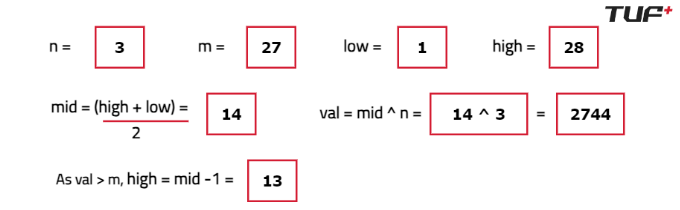
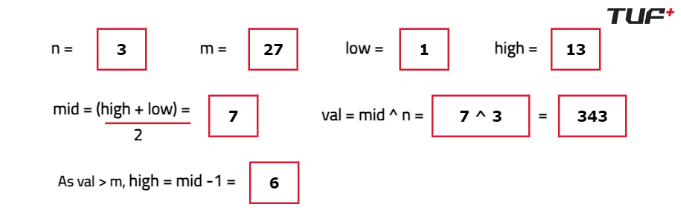
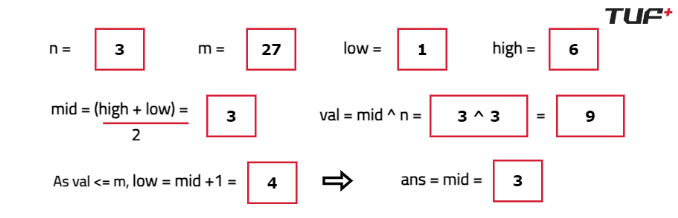
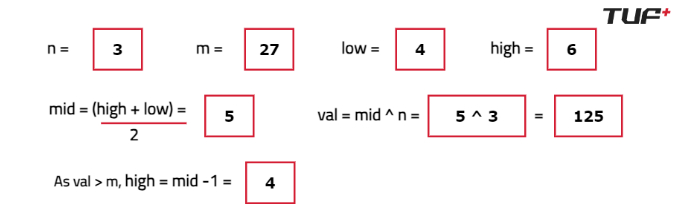
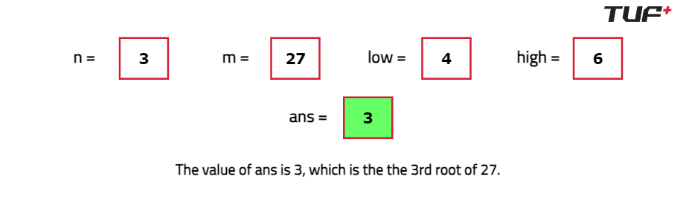

## Binary Search Python Solution

In [22]:
class Solution:
    # Helper function to check mid^N compared to M
    def helperFunc(self, mid, n, m):
        ans, base = 1, mid

        while n > 0:
            if n % 2 == 1:
                ans *= base
                if ans > m:
                    return 2  # Early exit
                n -= 1
            else:
                n //= 2
                base *= base
                if base > m:
                    return 2
        
        if ans == m:
            return 1
        return 0

    # Function to find the Nth root of M using Binary Search
    def NthRoot(self, N, M):
        low, high = 1, M
        
        while low <= high:
            mid = (low + high) // 2
            midN = self.helperFunc(mid, N, M)
            
            if midN == 1:
                return mid  # Found exact root
            elif midN == 0:
                low = mid + 1  # Move right
            else:
                high = mid - 1  # Move left
        
        return -1  # No integer root found

In [23]:
# Test case
n, m = 3, 27
sol = Solution()
ans = sol.NthRoot(n, m)
print("The answer is:", ans)

The answer is: 3


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(logM * logN).
This is because tTheBbinarySsearch on the search space (of size M) takes O(logM) and the helper function takes O(logN) taking overall O(logM * logN).
```

**Space Complexity:**
```
The Space Complexity will be O(1) as there are only a couple of variables used..
```

## FAQs & Interview Follow-ups :

**What happens if M is not a perfect N-th power?**
```
Binary search will terminate without finding mid^N=M. Return −1 in such cases, as the N-th root is not an integer.
```

**How do we avoid integer overflow when calculating mid^N?**
```
Instead of directly calculating mid^N, compute mid^N iteratively: Multiply mid^N times while checking if the result exceeds M. Stop early if overflow is detected.
```

**What if M and N are very large?**
```
For large M, calculate mid^N iteratively to prevent overflow. For large N, reduce the problem to smaller powers using modular arithmetic or logarithms (log(M)/N) to estimate the root.
```

**How would you extend this to multi-dimensional data?**
```
For matrices or tensors, compute the root element-wise using the same binary search logic. If the root must satisfy additional conditions (e.g., orthogonality), integrate those into the solution.
```

# 3. Koko Eating Bananas :

## Problem Statement :

A monkey is given n piles of bananas, where the 'ith' pile has nums[i] bananas. An integer h represents the total time in hours to eat all the bananas.

Each hour, the monkey chooses a non-empty pile of bananas and eats k bananas. If the pile contains fewer than k bananas, the monkey eats all the bananas in that pile and does not consume any more bananas in that hour.

Determine the minimum number of bananas the monkey must eat per hour to finish all the bananas within h hours.


### Examples :

**Example 1:**
```
Input: n = 4, nums = [7, 15, 6, 3], h = 8
Output: 5

Explanation: If Koko eats 5 bananas/hr, he will take 2, 3, 2, and 1 hour to eat the piles accordingly. So, he will take 8 hours to complete all the piles.  
```

**Example 2:**
```
Input: n = 5, nums = [25, 12, 8, 14, 19], h = 5
Output: 25

Explanation: If Koko eats 25 bananas/hr, he will take 1, 1, 1, 1, and 1 hour to eat the piles accordingly. So, he will take 5 hours to complete all the piles.
```

**Example 3:**
```
Input: n = 4, nums = [3, 7, 6, 11], h = 8
Output: 4

```
```
Constraints:
1 <= n <= 10^4
n <= h <= 10^9
1 <= nums[i] <= 10^9
```

# Linear Search

## Intuition

The straightforward solution for this problem is to use Linear Search algorithm to check all possible answers from 1 to max, where max is the maximum element of the array. The minimum number for which the required time is less than or equal to h, is our required answer.

## Approach

### Working of minimumRateToEatBananas(nums, h):

* First find out the maximum element in array by calling the 'findMax()'.
* Then , iterate from 1 to max which signifies the number of bananas eaten per hour, and for each iteration find out the hour taken to eat those bananas by calling calculateTotalHours ().
* If the calculated hour is less than or equal to given limit, return the current value of iteration (number of bananas) as an answer.
* If no suitable answer is found, return max element as an answer.

### Working of findMax(arr):

* First initialize a variable 'maxi', which will store maximum element of the array.
* Now, literate through the array and find the maximum element among them, and return it.

### Working of calculateTotalHours(arr,hourly):

* Start with initializing n = size of array, which gives the number of elements in the array. Initialize 'totalH' to 0, which will accumulate the total hours required. 'hourly' represents the number of items that can be processed per hour.
* Compute the number of hours required to eat all bananas at the rate of 'hourly' bananas per hour and store in 'totalH'. Use ceil function to round up the division result to ensure that partial hours are counted correctly when necessary. Ater the traversal has ended, return 'totalH' as answer.nswer.nswer.

## Linear Search Python Solution

In [24]:
import math

class Solution:
    # Helper function to find the maximum element in the list 
    def findMax(self, v):
        maxi = float('-inf')
        n = len(v)
        
        # Find the maximum element
        for i in range(n):
            maxi = max(maxi, v[i])
        return maxi

    """ Helper function to calculate total hours
        required at given hourly rate """
    def calculateTotalHours(self, v, hourly):
        totalH = 0
        n = len(v)
        
        # Calculate total hours required
        for i in range(n):
            totalH += math.ceil(v[i] / hourly)
        return totalH

    # Function to find the minimum rate to eat bananas 
    def minimumRateToEatBananas(self, nums, h):
        # Find the maximum number of bananas
        maxi = self.findMax(nums)

        """ Find the minimum value of k
            that satisfies the condition """
        for i in range(1, maxi + 1):
            reqTime = self.calculateTotalHours(nums, i)
            if reqTime <= h:
                return i

        """ Dummy return statement (should 
            not be reached in valid cases) """
        return maxi

In [25]:
# Driver Code
if __name__ == "__main__":
    v = [7, 15, 6, 3]
    h = 8

    # Create an object of the Solution class
    sol = Solution()

    ans = sol.minimumRateToEatBananas(v, h)

    # Print the result
    print(f"Koko should eat at least {ans} bananas/hr.")

Koko should eat at least 5 bananas/hr.


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(max * N), where max is the maximum element in the array and N is the size of the array. We are running nested loops. The outer loop runs for max times in the worst case and the inner loop runs for N times.
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no additional space is used.
```

# Binary Search

## Intuition

The idea here is to use Binary Search algorithm to solve this problem in an optimized way. Now, the search space will be in the range[1,max], where max is the maximum element in the array because the maximum bananas that the monkey can eat per hour can be the maximum element of the array. Since the search space is sorted, so binary search can be applied for better time complexity.

## Approach

### Working of minimumRateToEatBananas(nums, h):

* The function starts by initializing low to 1 (minimum possible eating rate) and high to maximum element of the array using findMax function, which finds the maximum element in the given array. This sets up the binary search bounds where the eating rate will be searched.
* Initialize a while loop that continues as long as low is less than or equal to high. Compute mid as the midpoint between low and high.
* Use the function calculateTotalHours to estimate how many hours would be needed to eat all bananas in the array at the rate `mid` bananas per hour.
* Compare total hour (total hours calculated at rate mid) with h (desired total hours). If total hour is less than or equal to h, it means the current eating rate mid is sufficient or possibly too high, so adjust high to mid - 1 to search for potentially smaller rates. Else, adjust low to mid + 1 to search for higher rates that might still satisfy the condition.
* Once the binary search completes (low > high), low represents the minimum eating rate such that eating all bananas within h hours is feasible.

### Working of findMax(arr):

* First initialize a variable 'maxi', which will store maximum element of the array.
* Now, literate through the array and find the maximum element among them, and return it.

### Working of calculateTotalHours(arr,hourly):

* Start with initializing n = size of array, which gives the number of elements in the array. Initialize 'totalH' to 0, which will accumulate the total hours required. 'hourly' represents the number of items that can be processed per hour.
* Compute the number of hours required to eat all bananas at the rate of 'hourly' bananas per hour and store in 'totalH'. Use ceil function to round up the division result to ensure that partial hours are counted correctly when necessary. Ater the traversal has ended, return 'totalH' as answer.

## Dry Run

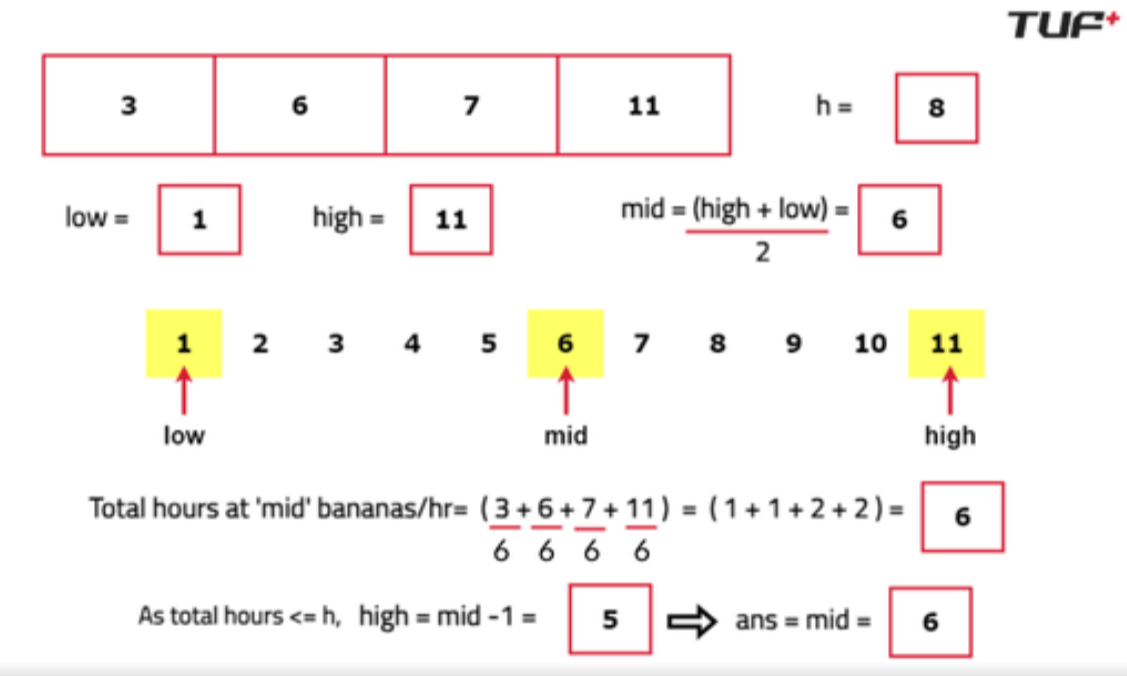
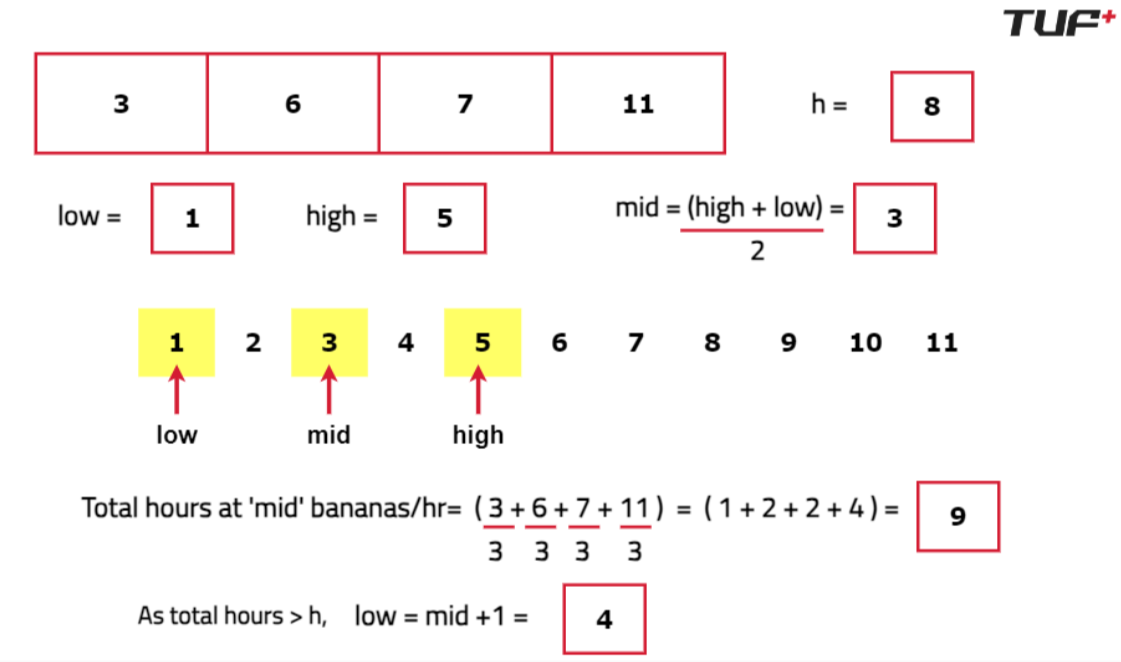
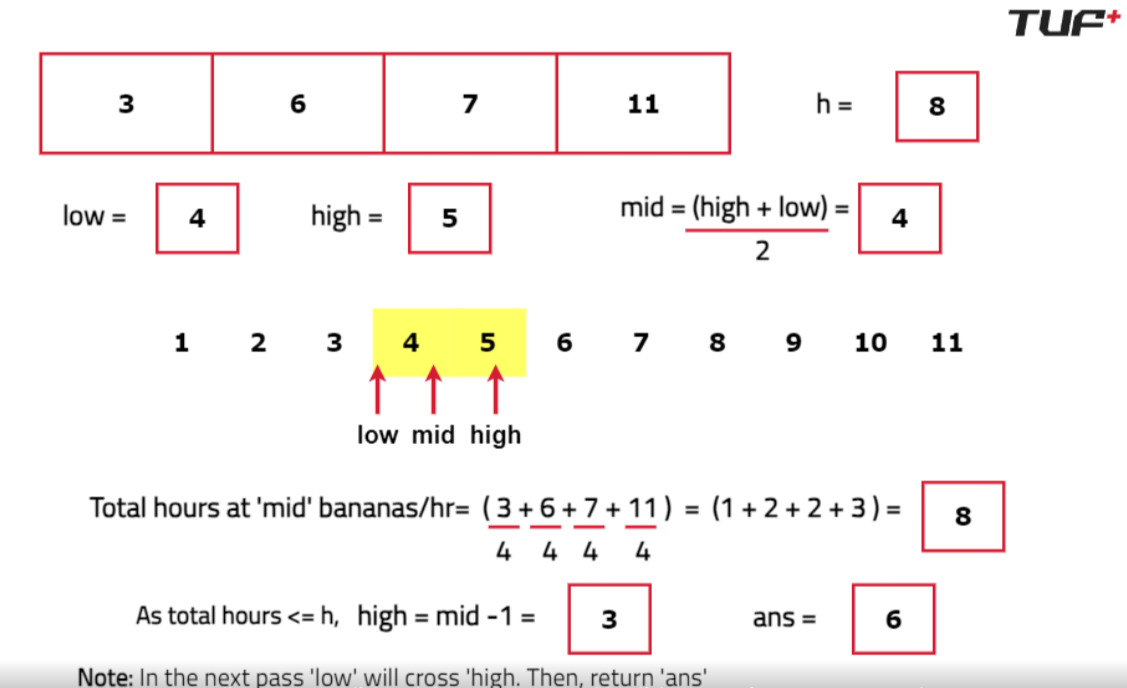

## Binary Search Python Solution

In [26]:
import math

class Solution:
    """ Helper function to find the
    maximum element in the array"""
    def findMax(self, nums):
        maxi = float('-inf')
        n = len(nums)

        # Find the maximum element
        for i in range(n):
            maxi = max(maxi, nums[i])
        return maxi

    """ Function to calculate total hours
    required at given hourly rate"""
    def calculateTotalHours(self, nums, hourly):
        totalH = 0
        n = len(nums)

        # Calculate total hours required
        for i in range(n):
            totalH += math.ceil(nums[i] / hourly)
        return totalH

    """ Function to find the 
    minimum rate to eat bananas"""
    def minimumRateToEatBananas(self, nums, h):
        # Initialize binary search bounds
        low, high = 1, self.findMax(nums)

        # Apply binary search
        while low <= high:
            mid = (low + high) // 2
            totalH = self.calculateTotalHours(nums, mid)
            if totalH <= h:
                high = mid - 1
            else:
                low = mid + 1
        return low

In [28]:
if __name__ == "__main__":
    nums = [3, 6, 7, 11]
    h = 8

    # Create an object of the Solution class
    sol = Solution()

    ans = sol.minimumRateToEatBananas(nums, h)

    # Print the result
    print(f"Koko should eat at least {ans} bananas/hr.")

Koko should eat at least 4 bananas/hr.


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N * log(max)), where max is the maximum element in the array and N is size of the array. We are applying Binary search for the range [1, max], and for every value of ‘mid’, we are traversing the entire array inside the function named calculateTotalHours().
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no additional space is used.
```

## FAQs & Interview Follow-ups :

**What if the total hours required exceeds h?**
```
If the hours exceed h for a given k, k is too small, and the monkey needs to eat faster. Adjust the Binary Search range by setting low=mid+1.
```

**How do we handle very large values of nums[i] or h?**
```
Use (nums[i]+k−1)//k instead of floating-point division to avoid precision issues and maintain integer operations. This ensures accuracy even with large inputs.
```

**How would you extend this for varying hourly capacities?**
```
If the monkey’s eating rate changes per hour (e.g., k depends on the hour), use a dynamic approach to calculate the minimum k for each hour, adjusting the binary search to consider these variations.
```

**What if the piles of bananas can be replenished?**
```
For dynamic or replenishing piles, track the rate of replenishment and modify the binary search to account for the changing size of nums[i] at each hour.
```

# 4. Minimum Days to make M Bouquets :

## Problem Statement :

Given n roses and an array nums where nums[i] denotes that the 'ith' rose will bloom on the nums[i]th day, and only adjacent bloomed roses can be picked to make a bouquet. Exactly k adjacent bloomed roses are required to make a single bouquet. 

<b>Find the minimum number of days required to make at least m bouquets, each containing k roses. Return -1 if it is not possible.</b>


### Examples :

**Example 1:**
```
Input: n = 8, nums = [7, 7, 7, 7, 13, 11, 12, 7], m = 2, k = 3
Output: 12

Explanation: Each value in nums corresponds to the count of days. On the 12th day, the first 4 flowers and the last 3 flowers would have already bloomed. So, we can easily make 2 bouquets, one with the first 3 and another with the last 3 flowers.
```

**Example 2:**
```
Input: n = 5, nums = [1, 10, 3, 10, 2], m = 3, k = 2
Output: -1

Explanation: If we want to make 3 bouquets of 2 flowers each, we need at least 6 flowers. But we are given only 5 flowers, so, we cannot make the bouquets.
```

**Example 3:**
```
Input: n = 5, nums = [1, 10, 3, 10, 2], m = 3, k = 1
Output: 3

```
```
Constraints:
1 <= n <= 10^5
1 <= nums[i] <= 10^9
1 <= m <= 10^6
1 <= k <= n
```

# Linear Search

### Intuition

The very straightforward approach is to check all possible answers from range min to max linearly, where min is the minimum element of the array and max is the maximum element of the array. Each number in the range shows the number of days. The minimum number of days for which at least 'm' bouquet can be made each containing 'k' rose will be our final answer.

## Approach

<b>Edge case:</b> If the product k*m (minimum number of roses required) is greater than size of the array, then it is impossible to make bouquet, and in that case return -1.

### Working of roseGarden(n, nums, k, m):

* Calculate val as the product of 'm' (number of bouquets) and 'k' (number of roses each bouquet should have), ensuring it's cast to long to avoid overflow. Determine the size n of the array.
* Initialize mini and maxi to INT_MAX and INT_MIN, respectively, to find the first day when a flower blooms and the last on which all fowers should have already bloomed.
* Iterate through the days starting from mini to maxi. For each day, use the possible function to check if the total number of bouquets on this day, each containing k roses is greater than or equal to "m". If yes, return the current day as an answer.
* After coming out of the loop, return -1 as no day is found matching the constraints.

### Working of possible(nums, day, k):

* First, initialize 'n' to the size of nums, which represents the number of flowers. Initialize 'cnt' to 0 which keeps track of how many flowers have bloomed within the current threshold day. Initialize 'noOfB' of 0, which keeps track of the total number of bouquets formed.
* The function iterates through each flower's blooming day in nums. For each flower, if its blooming day is less than or equal to day, increment 'cnt' (indicating a flower that can be used to form a bouquet). If a flower's blooming day exceeds day, calculate how many complete bouquets (cnt / k) can be formed with the flowers that bloomed up to that point (cnt). Add this count to noOfB. Reset 'cnt' to zero because flowers blooming after day cannot be used for the current bouquet.
* After iterating through all flowers, there might be remaining flowers (cnt) that have bloomed within day. Calculate how many additional bouquets can be formed with these remaining flowers and add this to noOfB.
* Finally, check if the total number of bouquets (noOfB) formed is greater than or equal to m. If so, return true, indicating that it's possible to form at least m bouquets with the given constraints (day and k).If not, return false.

## Linear Search Python Solution

In [29]:
 class Solution:
    """Function to check if it's possible to make
    m bouquets with k flowers each on a given day"""
    def possible(self, nums, day, m, k):
        n = len(nums)
        
        # Count of flowers bloomed
        cnt = 0 
        
        # Count of bouquets formed
        noOfB = 0 

        # Count number of bouquets that can be formed
        for i in range(n):
            if nums[i] <= day:
                # Increment flower count
                cnt += 1 
            else:
                # Calculate number of bouquets formed with flowers <= day
                noOfB += (cnt // k)
                
                # Reset flower count
                cnt = 0 
        
        # Add remaining flowers as a bouquet
        noOfB += (cnt // k) 
        
        # Return true if enough bouquets can be formed
        return noOfB >= m 

    """Function to find the earliest day to
    make m bouquets of k flowers each"""
    def roseGarden(self, n, nums, k, m):
        # Calculate the minimum number of flowers required
        val = m * k 
        
        # Impossible case: not enough flowers to make m bouquets
        if val > n:
            return -1 
        
        # Find maximum and minimum bloom days in the array
        mini = float('inf')
        maxi = float('-inf')
        for num in nums:
            mini = min(mini, num) 
            maxi = max(maxi, num) 
        
        # Linear search to find the earliest day to make m bouquets
        for i in range(mini, maxi + 1):
            if self.possible(nums, i, m, k):
                return i

        # Return -1 if no such day exists
        return -1 

In [30]:
if __name__ == "__main__":
    arr = [7, 7, 7, 7, 13, 11, 12, 7] 
    
    n = len(arr)
    
    # Number of flowers per bouquet
    k = 3 
    
    # Number of bouquets needed
    m = 2 

    # Create an instance of the Solution class
    sol = Solution() 
    
    ans = sol.roseGarden(n, arr, k, m) 

    if ans == -1:
        print("We cannot make m bouquets.") 
    else:
        print(f"We can make bouquets on day {ans}") 

We can make bouquets on day 12


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O((max-min+1) * N), where max is the maximum element of the array, min is the minimum element of the array, and N is size of the array.

This is because we are running a loop to check answers that are in the range of [min, max]. For every possible answer, the possible() function is being called. Inside the possible() function, we are traversing the entire array, which results in O(N).
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no additional space is used.
```

# Binary Search

### Intuition

The idea here is to use Binary Search algorithm as the search range [min, max] is sorted, where, min is the earliest and max is the latest day for a rose to bloom. So, if it's feasible to make m bouquets on day 'mid'((low+high)/2), eliminate the right half of the search space to search for an earlier day. Else, eliminate the left half to find a higher range of days. This way, the Brute Force solution can be optimized.

### Approach

<b>Edge case:</b> If the product k*m is greater than size of the array, then it is impossible to make bouquet, and in that case we can directly return -1.

### Working of roseGarden(n, nums, k, m):

* Initialize mini to INT_MAX and maxi to INT_MIN to find the earliest and latest bloom days in the nums array.
* Use Binary Search to find the earliest day (ans) where it’s possible to make m bouquets of k flowers each. Initialize left to mini and right to maxi. The range [low,high] defines the search space.
* While left is less than or equal to right, calculate the middle day 'mid'. Use the possible function to check if it's feasible to make m bouquets on day mid. If feasible, update ans to mid and move right to mid - 1 to search for an earlier day. Otherwise, move left to mid + 1 to search in the higher range of days.
* After the binary search completes, ans will hold the earliest day on which it's possible to make m bouquets of k flowers each. Return ans. If no such day exists (ans remains -1), return -1 indicating it's not possible under the given constraints.

### Working of possible(nums, day, k):

* First, initialize 'n' to the size of nums, which represents the number of flowers. Initialize 'cnt' to 0 which keeps track of how many flowers have bloomed within the current day threshold day. Initialize 'noOfB' of 0, which keeps track of the total number of bouquets formed.
* The function iterates through each flower's blooming day in nums. For each flower, if its blooming day is less than or equal to day, increment 'cnt' (indicating a flower that can be used to form a bouquet). If a flower's blooming day exceeds day, calculate how many complete bouquets (cnt / k) can be formed with the flowers that bloomed up to that point (cnt). Add this count to noOfB. Reset 'cnt' to zero because flowers blooming after day cannot be used for the current bouquet.
* After iterating through all flowers, there might be remaining flowers (cnt) that have bloomed within day. Calculate how many additional bouquets can be formed with these remaining flowers and add this to noOfB.
* Finally, check if the total number of bouquets (noOfB) formed is greater than or equal to m. If so, return true, indicating that it's possible to form at least m bouquets with the given constraints (day and k).If not, return false.

## Dry Run

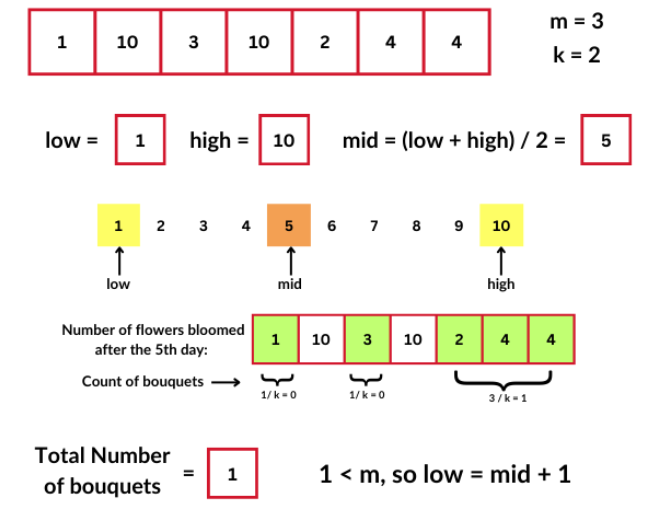
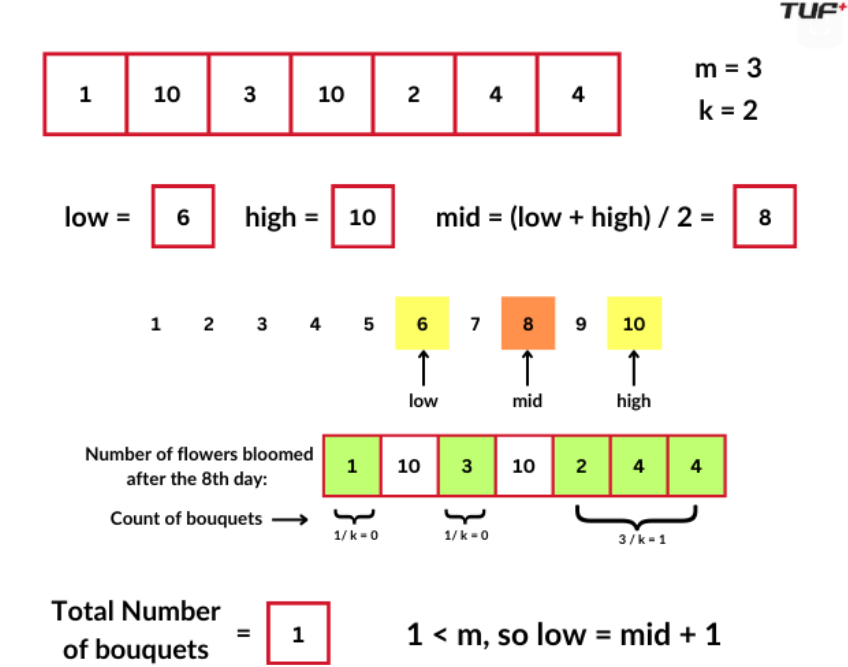
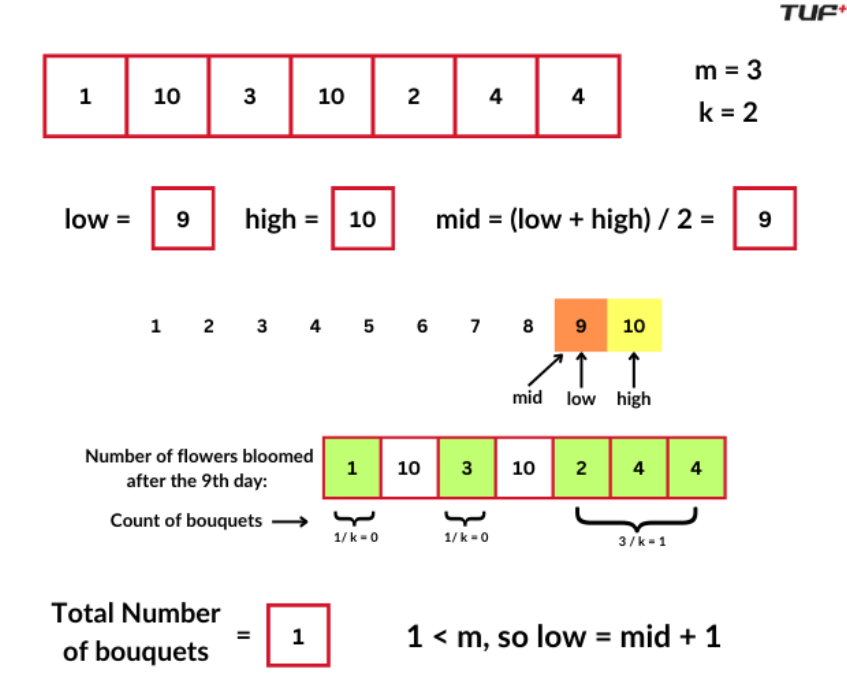
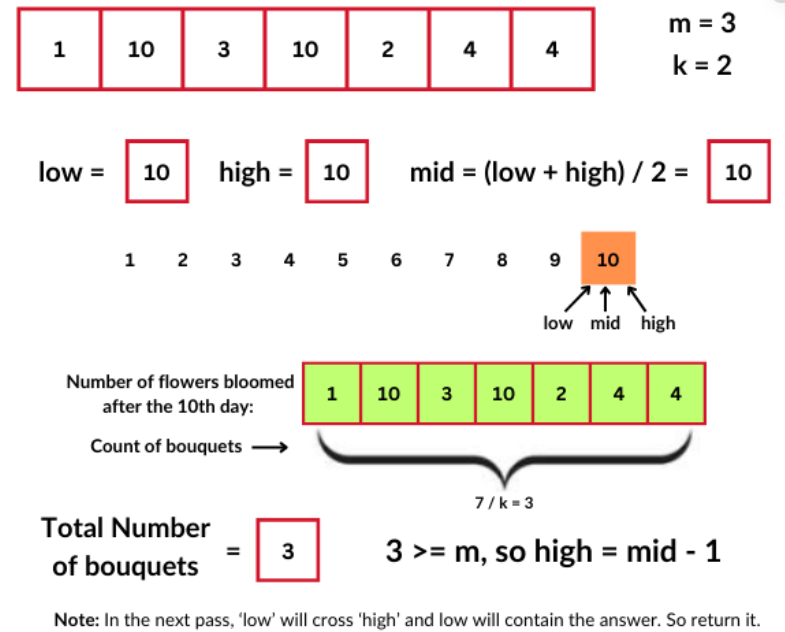

## Binary Search Python Solution

In [32]:
class Solution:
    """Function to check if it's possible to make
    m bouquets with k flowers each on day """
    def possible(self, nums, day, m, k):
        n = len(nums)
        
        # Count of flowers bloomed
        cnt = 0 
        
        # Count of bouquets formed
        noOfB = 0 

        # Count number of bouquets that can be formed
        for i in range(n):
            if nums[i] <= day:
                # Increment flower count
                cnt += 1 
            else:
                """ Calculate number of bouquets
                formed with flowers <= day """
                noOfB += (cnt // k)
                
                # Reset flower count
                cnt = 0 
        
        # Add remaining flowers as a bouquet
        noOfB += (cnt // k) 
        
        """ Return true if enough 
        bouquets can be formed """
        return noOfB >= m 

    """ Function to find the earliest day to
    make m bouquets of k flowers each """
    def roseGarden(self, n, nums, k, m):
        
        """ Calculate the minimum 
        number of flowers required """
        val = m * k 
        
        """ Impossible case: not enough 
            flowers to make m bouquets """
        if val > n:
            return -1 
        
        """ Find maximum and minimum
            bloom days in the array """
        mini = float('inf')
        maxi = float('-inf')
        for num in nums:
            mini = min(mini, num) 
            maxi = max(maxi, num) 
        
        """ Binary search to find the
            earliest day to make m bouquets """
        left = mini 
        right = maxi 
        ans = -1
        while left <= right:
            
            # Calculate the middle day
            mid = left + (right - left) // 2 
            
            """ Check if it's possible to 
                make m bouquets on day mid """
            if self.possible(nums, mid, m, k):
                
                # Update the answer to mid
                ans = mid 
                
                # Try for a smaller day
                right = mid - 1 
            else:
                left = mid + 1 
        
        """ Return the earliest day or 
        -1 if no such day exists"""
        return ans 

In [33]:
if __name__ == "__main__":
    arr = [7, 7, 7, 7, 13, 11, 12, 7] 
    
    n = len(arr)
    
    # Number of flowers per bouquet
    k = 3 
    
    # Number of bouquets needed
    m = 2 

    # Create an instance of the Solution class
    sol = Solution() 
    
    ans = sol.roseGarden(n, arr, k, m) 

    if ans == -1:
        print("We cannot make m bouquets.") 
    else:
        print(f"We can make bouquets on day {ans}") 

We can make bouquets on day 12


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(log(max-min+1) * N), where max is the maximum element of the array, min is the minimum element of the array, N is size of the array.

This is because we are running a loop to check answers that are in the range of [min, max]. For every possible answer, the possible() function is being called. Inside the possible() function, we are traversing the entire array, which results in O(N).
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no additional space is used.
```

## FAQs & Interview Follow-ups :

**How is bouquet feasibility checked efficiently?**
```
Use a single pass through the array on day d: Count consecutive roses that bloom on or before d. Reset the count whenever nums[i]>d. Stop early if m bouquets are formed, optimizing the simulation.
```

**Why use binary search to find the minimum days?**
```
Testing each day from 1 to max(nums) linearly has O(n⋅max(nums)) complexity, which is inefficient. Binary search narrows down the range logarithmically, significantly reducing the number of simulations.
```

**How would you handle non-adjacent bouquets?**
```
For non-adjacent bouquets, modify the simulation to track individual roses that bloom on or before d. Count all such roses and check if their total is sufficient to form m⋅k bouquets.
```

**What if the roses bloom asynchronously, with delays or dependencies?**
```
Model blooming as a graph, where edges represent dependencies. Use topological sorting to calculate effective blooming times and then apply the same binary search logic.
```

# 5. Find the Smallest Divisor :

## Problem Statement :

Given an array of integers nums and an integer limit as the threshold value, <b>find the smallest positive integer divisor such that upon dividing all the elements of the array by this divisor, the sum of the division results is less than or equal to the threshold value.</b>

After dividing each element by the chosen divisor, take the ceiling of the result (i.e., round up to the next whole number).


### Examples :

**Example 1:**
```
Input: nums = [1, 2, 3, 4, 5], limit = 8
Output: 3

Explanation: We can get a sum of 15 (1 + 2 + 3 + 4 + 5) if we choose 1 as a divisor. 

The sum is 9 (1 + 1 + 2 + 2 + 3) if we choose 2 as a divisor. Upon dividing all the elements of the array by 3, we get 1,1,1,2,2 respectively. Now, their sum is equal to 7 <= 8 i.e. the threshold value. So, 3 is the minimum possible answer.
```

**Example 2:**
```
Input: nums = [8,4,2,3], limit = 10
Output: 2

Explanation: If we choose 1, we get 17 as the sum. If we choose 2, we get 9 (4+2+1+2) <= 10 as the answer. So, 2 is the answer.
```

```
Constraints:
1 <= nums.length <= 5 * 10^4
1 <= nums[i] <= 10^6
nums.length <= limit <= 10^6
```

# Linear Search

### Intuition

The extremely naive approach is to use linear search to check all possible divisors from 1 to maximum element of the array. The minimum number for which the result is less than or equal to threshold value(limit), will be our answer.

### Approach

## FAQs & Interview Follow-ups :

**How does the rounding work for division?**
```
Instead of using ceil(nums[i]/d), compute (nums[i]+d−1)//d. This avoids floating-point arithmetic and directly calculates the rounded-up integer value.
```

**What happens if the threshold is very high?**
```
If the threshold is larger than or equal to the sum of elements when divided by 1 (i.e., ∑(nums)), the smallest divisor is 1, as no larger divisor is required.
```

**What if you need the largest divisor instead of the smallest?**
```
Reverse the Binary Search logic to prioritize larger divisors. Use the same sum calculation but adjust the bounds to find the maximum d that satisfies the condition.
```

**How would you optimize this for extremely large datasets?**
```
Divide the array into chunks, calculate partial sums for each chunk, and combine them dynamically during the binary search. This reduces memory usage and ensures scalability.
```